In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

img_1 = cv2.imread('../1540.jpg')
img_2 = cv2.imread('../1537.jpg')

img_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB).astype(np.float32)
img_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB).astype(np.float32)

assert img_1 is not None, "file could not be read, check with os.path.exists()"
assert img_2 is not None, "file could not be read, check with os.path.exists()"

## Linearity

In [10]:
def linear_system_blur(image):
    return cv2.blur(image, (3, 3))

In [12]:
# Scenario A: Add images FIRST, then filter
combined_img = img_1 + img_2
result_A = linear_system_blur(combined_img)
# plt.imshow(result_A, cmap='gray')

In [13]:
result_A

array([[[510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.],
        ...,
        [510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.]],

       [[510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.],
        ...,
        [510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.]],

       [[510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.],
        ...,
        [510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.]],

       ...,

       [[510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.],
        ...,
        [510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.]],

       [[510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.],
        ...,
        [510., 510., 510.],
        [510., 510., 510.],
        [510., 510., 510.]],

       [[510., 510., 510.],
        [510., 510., 510.],
        [510., 5

In [14]:
# Scenario B: Filter FIRST, then add
filtered_img1 = linear_system_blur(img_1)
filtered_img2 = linear_system_blur(img_2)
result_B = filtered_img1 + filtered_img2
# plt.imshow(result_B, cmap='gray')

In [15]:
# Check if they match (Additivity)
is_linear = np.allclose(result_A, result_B)
print(f"Does it satisfy Additivity? {is_linear}")

Does it satisfy Additivity? True


### Median Filter

In [16]:
import numpy as np

# A sample 3x3 pixel neighborhood from an image
patch = np.array([[12, 14, 17],
                  [10, 200, 15],  # Notice the 200 (a noise spike)
                  [11, 16, 13]])

# Step 1: Flatten the 2D patch into a 1D array
flattened = patch.flatten()
# [ 12, 14, 17, 10, 200, 15, 11, 16, 13 ]

# Step 2: Sort the array (This is the non-linear step!)
sorted_array = np.sort(flattened)
# [ 10, 11, 12, 13, 14, 15, 16, 17, 200 ]

# Step 3: Pick the middle value (index 4 out of 0-8)
median_value = np.median(sorted_array) # Or simply sorted_array[4]

print(f"Original center pixel: {patch[1, 1]}") # Output: 200
print(f"New median pixel: {median_value}")     # Output: 14.0

Original center pixel: 200
New median pixel: 14.0


### Mean Filter

In [17]:
import numpy as np

# The same 3x3 pixel neighborhood from an image
patch = np.array([[12, 14, 17],
                  [10, 200, 15],  # Notice the 200 (a noise spike)
                  [11, 16, 13]])

# Step 1: Sum all the pixel values in the patch (Additivity)
total_sum = np.sum(patch)
# 12 + 14 + 17 + 10 + 200 + 15 + 11 + 16 + 13 = 308

# Step 2: Divide by the number of pixels in the patch (Homogeneity/Scaling)
# Our patch is 3x3, so we divide by 9
mean_value = total_sum / patch.size 

print(f"Original center pixel: {patch[1, 1]}") # Output: 200
print(f"New mean pixel: {mean_value:.2f}")     # Output: 34.22

Original center pixel: 200
New mean pixel: 34.22


## Shift Invariance

In [33]:
# A 1D signal (Imagine this is a single row of pixels with a bright spot)
signal = np.array([0, 0, 100, 100, 100, 0, 0, 0, 0, 0], dtype=np.float32)
signal

array([  0.,   0., 100., 100., 100.,   0.,   0.,   0.,   0.,   0.],
      dtype=float32)

In [34]:
# Define our LSI system: A 3-pixel mean filter
kernel = np.array([1/3, 1/3, 1/3], dtype=np.float32)
kernel

array([0.33333334, 0.33333334, 0.33333334], dtype=float32)

In [35]:
# Scenario A: Filter the original signal
filtered_signal = cv2.filter2D(signal.flatten(), -1, kernel)
print("Original Filtered:", np.round(filtered_signal.flatten(), 1))

Original Filtered: [  0.   33.3  66.7 100.   66.7  33.3   0.    0.    0.    0. ]


In [36]:
# --- Now let's test Shift Invariance ---

# Shift the INPUT signal 3 positions to the right using np.roll
shifted_input = np.roll(signal, 3)
shifted_input

array([  0.,   0.,   0.,   0.,   0., 100., 100., 100.,   0.,   0.],
      dtype=float32)

In [37]:
# Scenario B: Filter the newly shifted input
filtered_shifted_input = cv2.filter2D(shifted_input.flatten(), -1, kernel)
filtered_shifted_input

array([[  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [ 33.333336],
       [ 66.66667 ],
       [100.00001 ],
       [ 66.66667 ],
       [ 33.333336],
       [  0.      ]], dtype=float32)

In [38]:
# Scenario C: Take our original output from Scenario A, and just shift it 3 positions
shifted_output = np.roll(filtered_signal, 3)
shifted_output

array([[  0.      ],
       [  0.      ],
       [  0.      ],
       [  0.      ],
       [ 33.333336],
       [ 66.66667 ],
       [100.00001 ],
       [ 66.66667 ],
       [ 33.333336],
       [  0.      ]], dtype=float32)

In [39]:
# If it is Shift Invariant, Scenario B and Scenario C must be identical
is_shift_invariant = np.allclose(filtered_shifted_input, shifted_output)
print(f"Is the system Shift Invariant? {is_shift_invariant}")

Is the system Shift Invariant? True


## Convolution

In [1]:
import cv2
import numpy as np

# 1. Create a dummy image: A black square with a white block in the middle
image = np.zeros((7, 7), dtype=np.float32)
image[2:5, 2:5] = 100.0  # The white block

# 2. Define our custom Vertical Edge Detection Kernel
# Left column is -1, center is 0, right column is 1
vertical_edge_kernel = np.array([[-1, 0, 1],
                                 [-1, 0, 1],
                                 [-1, 0, 1]], dtype=np.float32)

# 3. Apply the Convolution (Cross-Correlation)
# ddepth=-1 means the output image will have the same depth as the source
output_image = cv2.filter2D(image, ddepth=-1, kernel=vertical_edge_kernel)

print("Original Image:")
print(image)

print("\nConvolution Output (Vertical Edges Detected):")
print(output_image)

Original Image:
[[  0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.]
 [  0.   0. 100. 100. 100.   0.   0.]
 [  0.   0. 100. 100. 100.   0.   0.]
 [  0.   0. 100. 100. 100.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.]]

Convolution Output (Vertical Edges Detected):
[[   0.    0.    0.    0.    0.    0.    0.]
 [   0.  100.  100.    0. -100. -100.    0.]
 [   0.  200.  200.    0. -200. -200.    0.]
 [   0.  300.  300.    0. -300. -300.    0.]
 [   0.  200.  200.    0. -200. -200.    0.]
 [   0.  100.  100.    0. -100. -100.    0.]
 [   0.    0.    0.    0.    0.    0.    0.]]


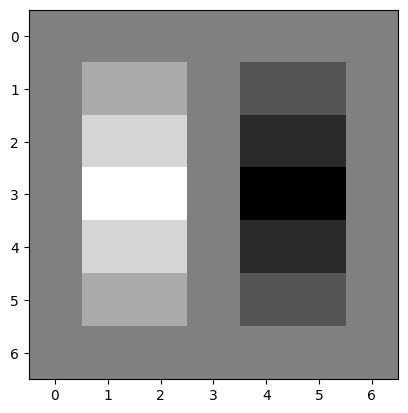

In [3]:
plt.imshow(output_image, cmap='gray')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-579..590].


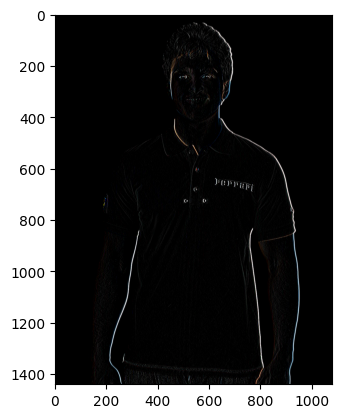

In [5]:
og_output_image = cv2.filter2D(img_1, ddepth=-1, kernel=vertical_edge_kernel)
plt.imshow(og_output_image.astype(np.int32), cmap='gray')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-500..504].


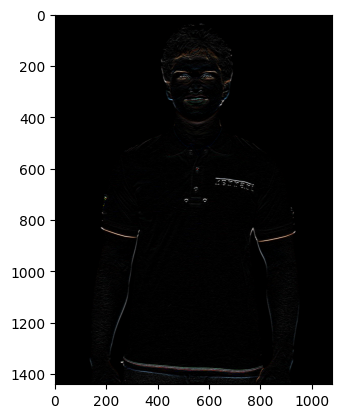

In [ ]:
horizontal_edge_kernel = np.array([[-1, -1, -1],
                                   [0, 0, 0],
                                   [1, 1, 1]], dtype=np.float32)
hor_output_image = cv2.filter2D(img_1, ddepth=-1, kernel=horizontal_edge_kernel)
plt.imshow(hor_output_image.astype(np.int32), cmap='gray')

In [9]:
print(img_1.shape)
print(hor_output_image.shape)

(1440, 1080, 3)
(1440, 1080, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1676..1850].


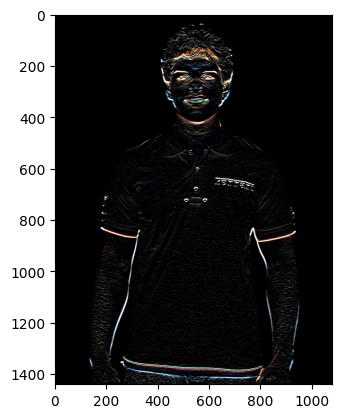

In [11]:
horizontal_edge_kernel_5_x_5 = np.array([[-1, -1, -1, -1, -1],
                                    [-1, -1, -1, -1, -1],
                                    [0, 0, 0, 0, 0],
                                    [1, 1, 1, 1, 1],
                                    [1, 1, 1, 1, 1],], dtype=np.float32)

hor_output_image = cv2.filter2D(img_1, ddepth=-1, kernel=horizontal_edge_kernel_5_x_5)
plt.imshow(hor_output_image.astype(np.int32), cmap='gray')

## Padding and Stride

In [12]:
import numpy as np
import cv2

# A simple 5x5 image
image = np.ones((5, 5), dtype=np.float32)

# --- 1. PADDING ---
# We add a 1-pixel border of 0s around the image
# 'constant' means fill with a constant value (0 by default)
padded_image = np.pad(image, pad_width=1, mode='constant', constant_values=0)

print(f"Original Shape: {image.shape}")       # (5, 5)
print(f"Padded Shape: {padded_image.shape}\n") # (7, 7)

# --- 2. STRIDE ---
# Let's say we applied a 3x3 filter and got a 7x7 output map back.
dummy_filtered_output = np.random.rand(7, 7)

# To simulate a Stride of 2, we just use NumPy slicing to skip every other row/column!
# Syntax: array[start:stop:step]
stride = 2
strided_output = dummy_filtered_output[::stride, ::stride]

print(f"Filtered Shape (Stride 1): {dummy_filtered_output.shape}") # (7, 7)
print(f"Filtered Shape (Stride 2): {strided_output.shape}")        # (4, 4)

Original Shape: (5, 5)
Padded Shape: (7, 7)

Filtered Shape (Stride 1): (7, 7)
Filtered Shape (Stride 2): (4, 4)
